# MiraiChem: H2 end-to-end demo

**Team Mirai · Q-Hack India 2026 · Quantum Biotech & Chemistry**

This notebook runs the whole MiraiChem pipeline on the hydrogen molecule (H2), top to bottom, in a
few minutes on a laptop. Every cell only **calls the `miraichem` package**; the logic lives in `src/`.

1. Classical reference energies (Hartree-Fock and exact)
2. The qubit Hamiltonian, with two fermion-to-qubit mappings
3. One VQE run on an ideal simulator
4. The same problem on a **noisy** simulator, with and without error mitigation
5. A sweep of VQE configurations, ranked, with a Pareto front and a recommendation
6. A dissociation curve, and why judging a configuration at one bond length can mislead
7. Real IBM hardware: the cost gate (dry run) and the results we measured earlier

All energies are **total energies in Hartree** (Ha); errors are in milli-Hartree (mHa). *Chemical
accuracy* means an error below **1.6 mHa**. Nothing here uses real hardware time: step 7 only reads
results saved earlier.

In [1]:
import tempfile
import warnings
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

warnings.filterwarnings("ignore")

from miraichem.analysis.dissociation import compute_curve, plot_curve_png
from miraichem.analysis.plots import plot_convergence, plot_pareto
from miraichem.backends.hardware import estimate_plan
from miraichem.benchmark.ranking import ranking_dataframe, recommend
from miraichem.benchmark.ranking_scan import recommend_across_scan
from miraichem.benchmark.report import load_hardware_results
from miraichem.benchmark.storage import load_all_results
from miraichem.benchmark.sweep import load_sweep_config, run_sweep
from miraichem.chemistry.classical import compute_reference
from miraichem.config import MoleculeConfig, RunConfig
from miraichem.dashboard_helpers import hardware_table
from miraichem.mapping.hamiltonian import build_qubit_hamiltonian, exact_ground_energy
from miraichem.vqe.runner import run_vqe

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = Path(tempfile.mkdtemp(prefix="miraichem_demo_"))  # demo runs are saved here
BOND = 0.735  # Angstrom, the equilibrium bond length of H2
print("Setup complete. Demo runs are saved to a temporary folder.")

Setup complete. Demo runs are saved to a temporary folder.


## 1. Classical reference energies

We describe the molecule in a config file (geometry in Angstrom, STO-3G basis) and ask PySCF for two
reference energies:

- **Hartree-Fock (HF)**: the best single-configuration (mean-field) answer. Fast, but it misses
  electron correlation.
- **Exact (FCI)**: the exact answer inside this basis. This is the target any VQE should reach.

The gap between them is the **correlation energy** that VQE has to recover.

In [2]:
h2 = MoleculeConfig(**yaml.safe_load((ROOT / "configs" / "molecules" / "h2.yaml").read_text()))
ref = compute_reference(h2, BOND)

pd.DataFrame(
    {
        "energy (Ha)": [ref.e_hf, ref.e_exact, ref.e_nuclear_repulsion],
        "meaning": [
            "Hartree-Fock (total)",
            f"exact, {ref.exact_method} (total)",
            "nuclear repulsion (included above)",
        ],
    },
    index=["HF", "exact", "nuclear"],
).round(6).T

,HF,exact,nuclear
energy (Ha),-1.116999,-1.137306,0.719969
meaning,Hartree-Fock (total),"exact, FCI (total)",nuclear repulsion (included above)


In [3]:
print(f"Correlation energy HF -> exact: {(ref.e_hf - ref.e_exact) * 1000:.1f} mHa")
print(f"Qubits needed with Jordan-Wigner: {ref.n_qubits_expected}")

Correlation energy HF -> exact: 20.3 mHa
Qubits needed with Jordan-Wigner: 4


## 2. The qubit Hamiltonian

A quantum computer works with qubits, but electrons are fermions. A **mapper** rewrites the molecular
Hamiltonian as a sum of Pauli strings acting on qubits:

- **Jordan-Wigner**: one qubit per spin-orbital (4 qubits for H2).
- **Parity**: an equivalent encoding that lets us drop 2 qubits, because the electron-number parity is
  conserved. Fewer qubits means a shallower circuit, which matters a lot on noisy hardware.

Correctness check: the lowest eigenvalue of each qubit Hamiltonian (plus the constant energy shift) must
equal the exact PySCF energy.

In [4]:
rows = []
for mapping in ("jordan_wigner", "parity"):
    problem = build_qubit_hamiltonian(h2, BOND, mapping)
    e0 = exact_ground_energy(problem)
    rows.append(
        {
            "mapping": mapping,
            "qubits": problem.num_qubits,
            "Pauli terms": len(problem.hamiltonian),
            "ground energy (Ha)": round(e0, 8),
            "difference from exact (Ha)": f"{abs(e0 - ref.e_exact):.1e}",
        }
    )
pd.DataFrame(rows)

,mapping,qubits,Pauli terms,ground energy (Ha),difference from exact (Ha)
0,jordan_wigner,4,15,-1.137306,8.9e-16
1,parity,2,5,-1.137306,1.8e-15


## 3. One VQE run on an ideal simulator

**VQE** guesses the ground state with a parameterised circuit (the **ansatz**), measures its energy, and
lets a classical **optimizer** adjust the parameters to lower it. By the variational principle the energy
can never fall below the exact value.

Here: the chemistry-inspired **UCCSD** ansatz starting from the Hartree-Fock state, the Parity mapping,
and the L-BFGS-B optimizer, on an ideal (noise-free, exact) simulator.

In [5]:
ideal_cfg = RunConfig(
    molecule=h2, bond_length=BOND, mapping="parity", ansatz="uccsd",
    optimizer="lbfgsb", backend="ideal", maxiter=200, seed=42,
)
ideal = run_vqe(ideal_cfg)

print(f"status              : {ideal.status}")
print(f"VQE energy          : {ideal.e_vqe:.6f} Ha")
print(f"exact energy        : {ideal.e_exact:.6f} Ha")
print(f"error               : {ideal.abs_error_mha:.4f} mHa  (chemical accuracy: below 1.6 mHa)")
print(f"within chem. acc.   : {ideal.within_chemical_accuracy}")
print(f"qubits / parameters : {ideal.num_qubits} / {ideal.num_params}")
print(f"energy evaluations  : {ideal.n_function_evals}")

status              : ok
VQE energy          : -1.137306 Ha
exact energy        : -1.137306 Ha
error               : 0.0000 mHa  (chemical accuracy: below 1.6 mHa)
within chem. acc.   : True
qubits / parameters : 2 / 3
energy evaluations  : 33


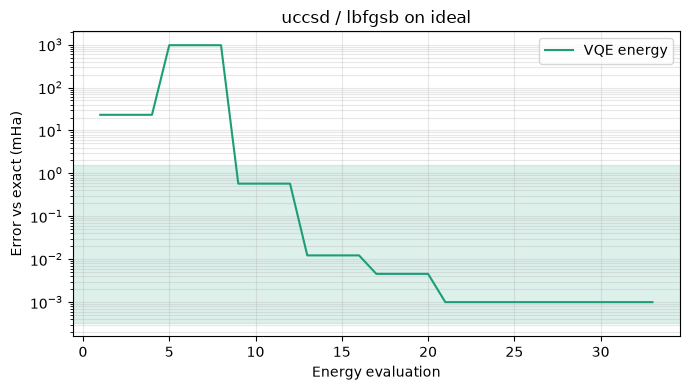

In [6]:
plot_convergence(ideal);

## 4. The same problem on a noisy simulator

Real quantum computers are noisy. The **noisy simulator** copies the noise model, gate set and connectivity
of a real IBM device (`FakeSherbrooke`), samples a finite number of shots, and runs the *transpiled*
circuit. We run the same UCCSD problem twice:

- **no mitigation**
- **readout + ZNE mitigation**: *readout* correction undoes measurement errors; *zero-noise extrapolation
  (ZNE)* runs the circuit at amplified noise levels and extrapolates back to zero noise.

Both energies are recorded for every evaluation, so "before vs after" comes for free.

In [7]:
def noisy_cfg(mitigation):
    return RunConfig(
        molecule=h2, bond_length=BOND, mapping="parity", ansatz="uccsd", optimizer="cobyla",
        backend="noisy", fake_backend_name="FakeSherbrooke", shots=1024, maxiter=60,
        mitigation=mitigation, seed=42,
    )

raw = run_vqe(noisy_cfg("none"))
mitigated = run_vqe(noisy_cfg("readout+zne"))

pd.DataFrame(
    {
        "none": [raw.abs_error_mha, raw.two_qubit_gates, raw.transpiled_depth, raw.total_shots],
        "readout + zne": [
            mitigated.abs_error_mha, mitigated.two_qubit_gates,
            mitigated.transpiled_depth, mitigated.total_shots,
        ],
    },
    index=["error (mHa)", "two-qubit gates", "transpiled depth", "total shots"],
).round(2)

,none,readout + zne
error (mHa),43.27,24.03
two-qubit gates,4.00,4.00
transpiled depth,38.00,38.00
total shots,67584.00,120832.00


Mitigated run, final energy: raw -1.0759 Ha  ->  mitigated -1.1133 Ha
Exact energy: -1.1373 Ha


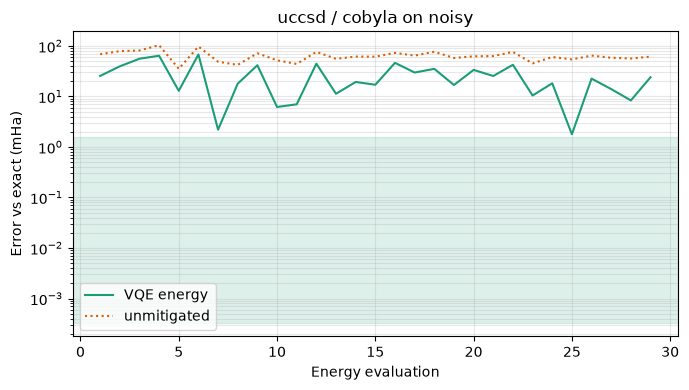

In [8]:
print(f"Mitigated run, final energy: raw {mitigated.e_vqe_unmitigated:.4f} Ha  ->  mitigated {mitigated.e_vqe:.4f} Ha")
print(f"Exact energy: {mitigated.e_exact:.4f} Ha")
plot_convergence(mitigated);

Mitigation costs extra shots (see *total shots*) and moves the energy much closer to the exact value, but
it does not remove the noise. The mitigated energy can even land slightly *below* the exact value: that is
statistical scatter from shot noise and the extrapolation, not a violation of the variational principle,
which applies to exact expectation values. Which settings give the best trade-off? That is what the
benchmark answers.

## 5. Sweep, rank, recommend

MiraiChem expands a **sweep config** into every combination of mapping, ansatz, optimizer, backend and
mitigation, runs each one (skipping any already saved), and saves one JSON file per run. Finished runs are
cached by config hash, so a sweep can be stopped and resumed. This is the small `quick_h2` sweep (16
runs; about a minute with 4 worker processes).

In [9]:
sweep = load_sweep_config(ROOT / "configs" / "sweeps" / "quick_h2.yaml")
summary = run_sweep(sweep, RESULTS, max_workers=4, show_progress=False)
print(f"{summary.n_total} runs: {summary.n_ran} ran, {summary.n_cached} cached, {summary.n_failed} failed")

16 runs: 16 ran, 0 cached, 0 failed


Now **rank** the noisy runs. The score combines three costs (accuracy weighs most, then two-qubit gates,
then shots). The **Pareto front** marks runs that no other run beats on both error and cost.
`recommend()` then picks the cheapest run that reaches chemical accuracy, or the best-scoring run if none
does, and explains itself with the real numbers.

In [10]:
rec = recommend(summary.results, "h2", "noisy")
print(rec.justification)

Recommended for h2 on the noisy backend (bond length 0.735 A): uccsd(reps=1)/cobyla, jordan_wigner, readout+zne. Its energy error is 158 mHa (Hartree-Fock alone is off by 20.3 mHa), using 49 two-qubit gates and 288,768 shots. None of the 4 runs reached chemical accuracy (1.6 mHa); this is the best-scoring one, so treat the result as the least bad option, not as accurate. It lies on the Pareto front for error vs shots and error vs two-qubit gates.


In [11]:
cols = ["rank", "ansatz", "reps", "optimizer", "mapping", "mitigation",
        "error_mHa", "chemical_accuracy", "two_qubit_gates", "total_shots"]
ranking_dataframe(rec.ranked)[cols].head(8)

,rank,ansatz,reps,optimizer,mapping,mitigation,error_mHa,chemical_accuracy,two_qubit_gates,total_shots
0,1,uccsd,1,cobyla,jordan_wigner,readout+zne,157.682045,False,49,288768
1,2,uccsd,1,cobyla,jordan_wigner,none,274.564131,False,49,153600
2,3,hea,1,cobyla,jordan_wigner,none,1999.494821,False,3,414720
3,4,hea,1,cobyla,jordan_wigner,readout+zne,2083.826069,False,3,831488


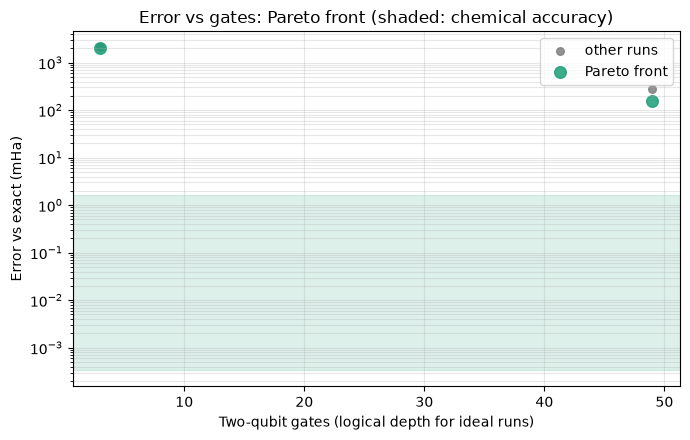

In [12]:
plot_pareto(rec.ranked, "gates");

## 6. A dissociation curve, and why one geometry is not enough

Stretch the H-H bond and Hartree-Fock gets steadily worse, because the two electrons become strongly
correlated. A good VQE should follow the exact curve at *every* bond length, not only near equilibrium.

The best configuration at the equilibrium bond length is not always the best over the whole curve. We scan
two ideal-backend configurations over 7 bond lengths: the one the single-geometry ranking recommends, and
the chemistry-inspired UCCSD.

In [13]:
ideal_rec = recommend(summary.results, "h2", "ideal")
print("Recommended at equilibrium:", ideal_rec.best.label)

bonds = [0.4, 0.6, 0.735, 1.0, 1.5, 2.0, 2.5]
at_equilibrium = ideal_rec.best.result.config
uccsd = at_equilibrium.model_copy(update={"ansatz": "uccsd", "ansatz_reps": 1, "optimizer": "lbfgsb", "maxiter": 200})
curves = {
    "recommended at equilibrium": compute_curve(at_equilibrium, bonds, RESULTS, max_workers=4),
    "UCCSD / L-BFGS-B": compute_curve(uccsd, bonds, RESULTS, max_workers=4),
}
pd.DataFrame(
    {
        name: {
            "worst error (mHa)": round(c.max_vqe_error_mha, 3),
            "within 1.6 mHa": f"{c.fraction_chemically_accurate:.0%} of bond lengths",
        }
        for name, c in curves.items()
    }
)

Recommended at equilibrium: uccsd(reps=1)/cobyla, parity


,recommended at equilibrium,UCCSD / L-BFGS-B
worst error (mHa),0.137,0.0
within 1.6 mHa,100% of bond lengths,100% of bond lengths


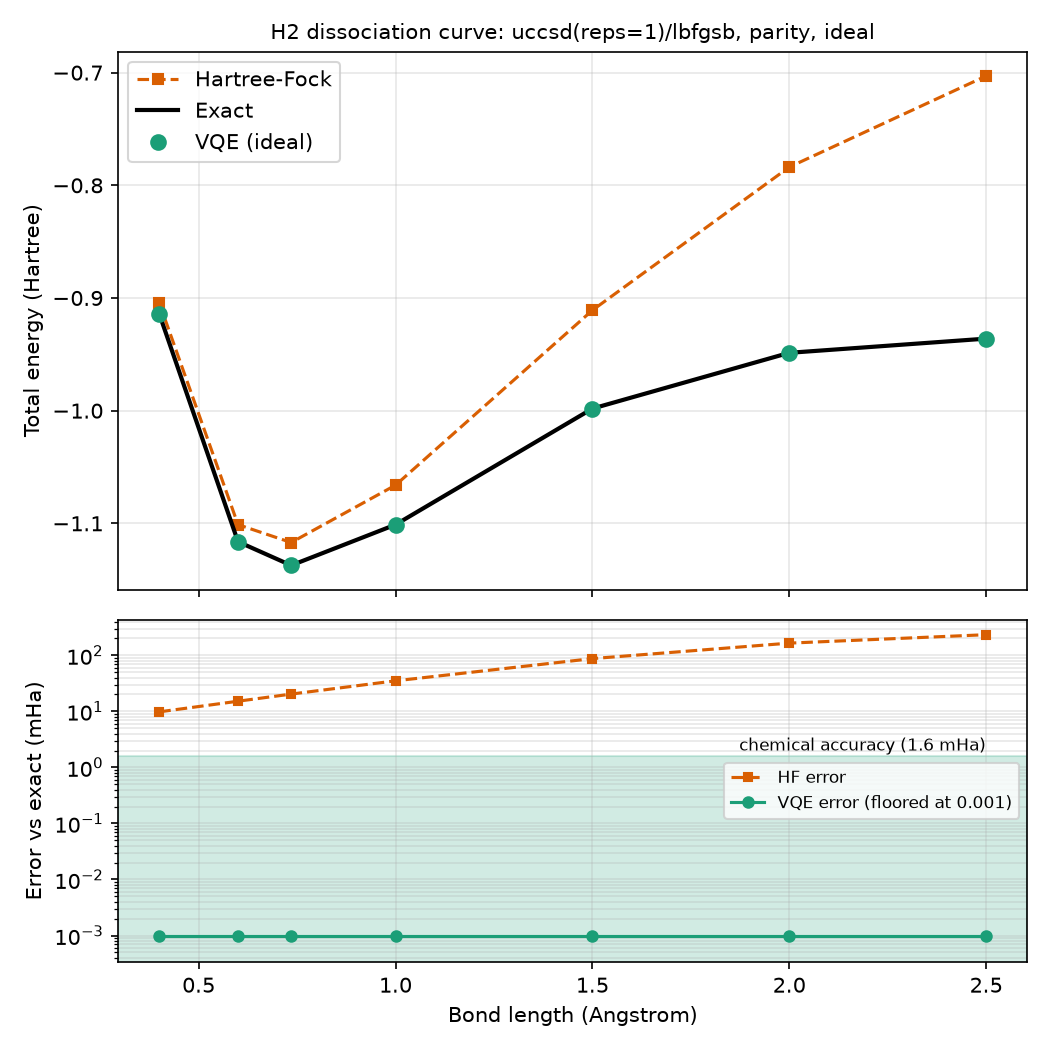

In [14]:
display(Image(filename=str(plot_curve_png(curves["UCCSD / L-BFGS-B"], RESULTS / "curve_uccsd.png"))))

Judging configurations by their **worst case over a scan** (and the share of bond lengths that are
chemically accurate) therefore gives a more reliable recommendation than a single geometry:

In [15]:
scan_rec = recommend_across_scan(load_all_results(RESULTS), "h2", "ideal")
print(scan_rec.justification)

Recommended for h2 on the ideal backend across a scan of 7 bond lengths (0.4 to 2.5 A): uccsd(reps=1)/lbfgsb, parity. Its worst-case error is 0.001 mHa (mean 0.001 mHa), it is within chemical accuracy (1.6 mHa) at 100% of the bond lengths, and it uses on average 18 logical depth and 0 shots per point. It is the cheapest of the 2 (of 2) scanned configurations that stay chemically accurate at every bond length. For contrast, uccsd(reps=1)/cobyla, parity is within chemical accuracy at 100% of the bond lengths with a worst-case error of 0.137 mHa.


## 7. Real IBM hardware

Real quantum time is scarce (the free plan allows 600 s per period), so hardware is **off by default** and
gated. The `miraichem hardware` command first prints a cost estimate and requires an explicit
`--allow-hardware` flag plus a `y/N` confirmation. We evaluate the *optimal parameters found on the
simulator* once per mitigation setting on the device, instead of running a whole optimisation there.

This cell shows the cost estimate for such a run. **Nothing is submitted.**

In [16]:
n_groups = len(build_qubit_hamiltonian(h2, BOND, "parity").hamiltonian.group_commuting(qubit_wise=True))
plan = estimate_plan("a real IBM device", ["none", "readout+zne"], shots=4096, num_groups=n_groups)
print("\n".join(plan.lines()))

Backend         : a real IBM device
Mitigation modes: none, readout+zne
Jobs            : 2
Circuits (total): 8
Shots per circuit: 4096
Estimated QPU time: ~43 s (rough upper-bound estimate)


**Results we measured earlier on a real device** (`ibm_fez`, 4096 shots, saved in
`results/published/hardware/`). These are real hardware numbers, not simulation. The UCCSD run below used
the optimal parameters from the simulator, evaluated once per mitigation mode.

In [17]:
hardware = load_hardware_results(ROOT / "results" / "published" / "hardware")
uccsd_hw = next(h for h in hardware if h.source_config_hash == "4851787063fb")  # UCCSD / Parity run
print(f"{uccsd_hw.molecule} on {uccsd_hw.backend}, {uccsd_hw.shots} shots, source simulator run {uccsd_hw.source_config_hash}")
pd.DataFrame(hardware_table(uccsd_hw)).round(4)

H2 on ibm_fez, 4096 shots, source simulator run 4851787063fb


,Source,Energy (Ha),Error (mHa),Kind
0,Exact,-1.1373,0.0000,reference
1,Ideal circuit,-1.1369,0.4415,noiseless simulation
2,Simulator (readout+zne),-1.1367,0.5771,noisy simulator
3,Hardware (none),-1.0529,84.4504,"REAL DEVICE, job db0jbi3id5ic73ept53g"
4,Hardware (readout),-1.1116,25.7025,"REAL DEVICE, job db0jbnjid5ic73ept5j0"
5,Hardware (zne),-1.0637,73.6391,"REAL DEVICE, job db0jbu3id5ic73ept5ug"
6,Hardware (readout+zne),-1.1343,3.0211,"REAL DEVICE, job db0jc2pb694s73dr2cug"


On the device, **readout + ZNE mitigation took the error from tens of mHa to a few mHa**. A single run has a
statistical error of several mHa, so the best hardware results cannot be told apart from chemical accuracy.
See the README and `docs/RESULTS.md` for all hardware comparisons and the honest limitations.

## What next?

- Explore every saved result interactively: `streamlit run dashboard/app.py`
- Rerun the benchmark: `miraichem sweep configs/sweeps/full_h2.yaml --max-workers 4`
- Read how it works and why: `README.md`, `docs/DECISIONS.md`, `docs/RESULTS.md`